<a href="https://colab.research.google.com/github/Glaze0/Assignment/blob/main/08_The_art_and_science_of_visual_storytelling_with_charts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Art and Science of Visual Storytelling with Charts

## Problem Statment

You are an analyst on **Amazon India's category planning team**.

The VP of Categories runs the annual review on Monday. You have **one year of order data — 5,877 orders**,
Answer the below questions?

| question | What to decide with it |
|---|---|
| What does a typical order look like? | where to set free-delivery thresholds |
| Which category actually carries the business? | next year's budget split |
| When did the year happen? | when to hold the next sale |
| Is discounting buying growth or buying losses? | the discount policy |
---

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings;
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 4)

In [ ]:
!gdown 1M5fei1S_9qP4dwINjwK0bvCOXbOfucY9

Downloading...
From: https://drive.google.com/uc?id=1M5fei1S_9qP4dwINjwK0bvCOXbOfucY9
To: /content/amazon_india_orders.csv
100% 351k/351k [00:00<00:00, 146MB/s]


In [ ]:
orders = pd.read_csv('amazon_india_orders.csv')
print(orders.shape)
orders.head()

(5877, 9)


,order_date,month,category,region,prime_member,order_value,discount_pct,delivery_days,profit
0,2025-01-01,Jan,Fashion,West,Prime,1872.0,33.0,1.0,-112.0
1,2025-01-01,Jan,Fashion,South,Non-Prime,908.0,54.0,1.7,-214.0
2,2025-01-01,Jan,Beauty,East,Non-Prime,552.0,29.0,5.3,-4.0
3,2025-01-01,Jan,Home & Kitchen,East,Prime,1674.0,30.0,2.0,37.0
4,2025-01-01,Jan,Home & Kitchen,South,Non-Prime,820.0,39.0,2.1,-59.0



| Column | Meaning |
|---|---|
| `order_date`, `month` | when the order was placed |
| `category` | Electronics, Fashion, Home & Kitchen, Beauty, Grocery |
| `region` | North, South, East, West |
| `prime_member` | Prime or Non-Prime |
| `order_value` | what the customer paid, ₹ |
| `discount_pct` | discount applied, 0–60 % |
| `delivery_days` | order placed → delivered |
| `profit` | Amazon's margin on that order, ₹ (**can be negative**) |


How to take decision:
| The question  | You are showing | Chart | seaborn |
|---|---|---|---|
| "What's typical? What's the spread?" | **distribution** | histogram, box plot | `histplot`, `boxplot` |
| "Which one is biggest?" | **comparison** | bar chart | `barplot`, `countplot` |
| "Is it going up?" | **trend** | line chart | `lineplot` |
| "Does X move with Y?" | **relationship** | scatter plot | `scatterplot` |

###  What does a typical order look like? → **distribution**

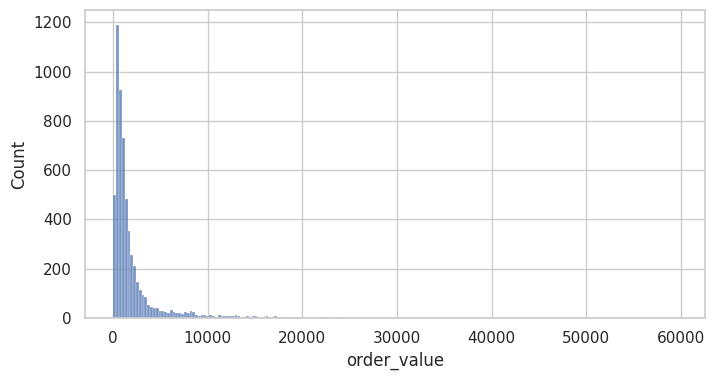

In [ ]:
sns.histplot(data=orders, x="order_value", bins=200);

In [ ]:
(orders['order_value'] <=0).sum()

np.int64(0)

In [ ]:
print("mean   ₹", round(orders["order_value"].mean()))
print("median ₹", round(orders["order_value"].median()))

mean   ₹ 2233
median ₹ 1070


In [ ]:
np.percentile(orders['order_value'], 20)

np.float64(519.0)

In [ ]:
# np.log(orders['order_value'])

<Axes: xlabel='order_value', ylabel='Count'>

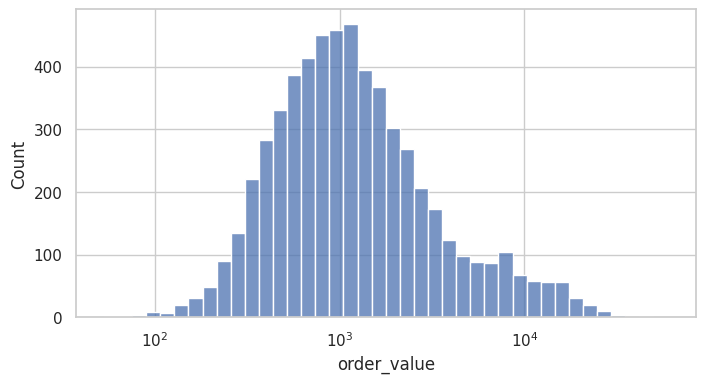

In [ ]:
sns.histplot(data=orders, x="order_value", bins=40, log_scale=True) # log scale



### Which category carries the business? → **comparison**

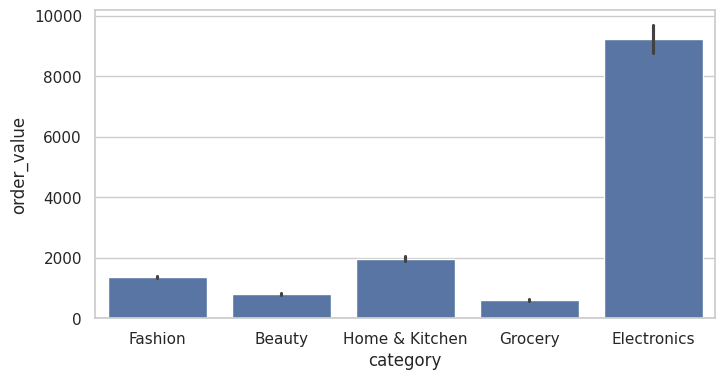

In [ ]:
sns.barplot(data=orders, x="category", y="order_value", );

In [ ]:
orders.groupby('category')['order_value'].sum()

,order_value
category,
Beauty,815675.0
Electronics,6872740.0
Fashion,2463996.0
Grocery,691960.0
Home & Kitchen,2279574.0


In [ ]:
orders.groupby('category')['order_value'].sum() / orders['order_value'].sum()

,order_value
category,
Beauty,0.062152
Electronics,0.523679
Fashion,0.187748
Grocery,0.052725
Home & Kitchen,0.173696


<Axes: xlabel='category', ylabel='order_value'>

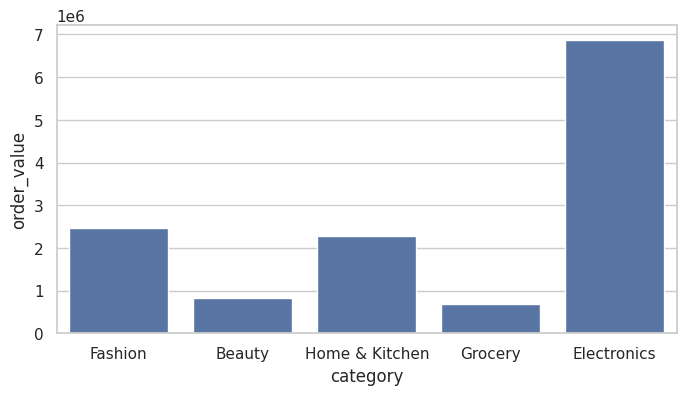

In [ ]:
sns.barplot(data=orders, x="category", y="order_value", estimator="sum", errorbar=None)

###  When did the year actually happen? → **trend**

In [ ]:
# orders.groupby("order_date")["order_value"].sum()

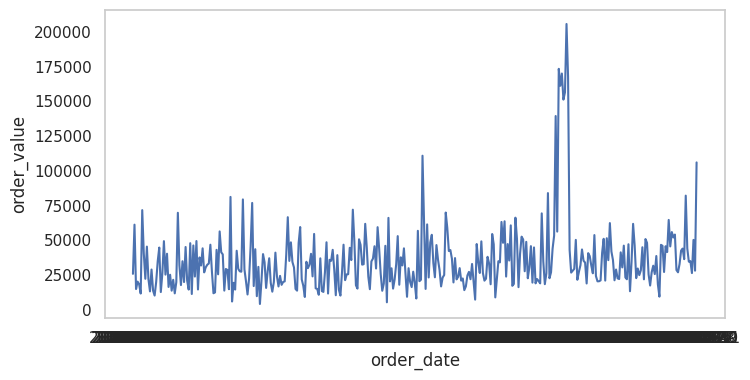

In [ ]:
daily = orders.groupby("order_date")["order_value"].sum().reset_index()
sns.lineplot(data=daily, x="order_date", y="order_value")
plt.grid(False)
plt.show()

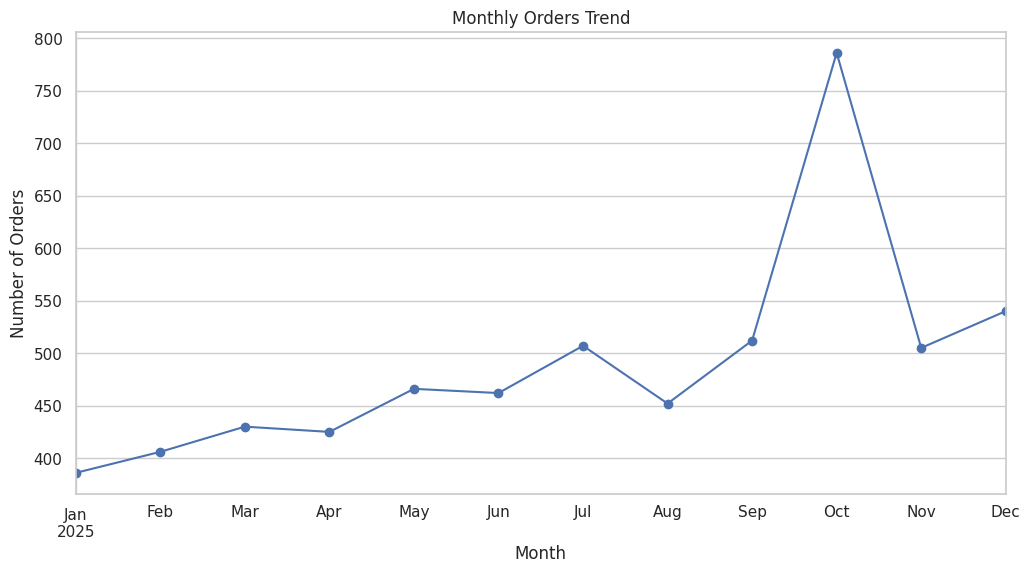

In [ ]:
df = orders
df["date"] = pd.to_datetime(df["order_date"])

monthly_orders = df.groupby(
    df["date"].dt.to_period("M")
).size()

monthly_orders.plot(kind="line", marker="o", figsize=(12, 6))
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.title("Monthly Orders Trend")
plt.show()

### Is discounting working? → **relationship**

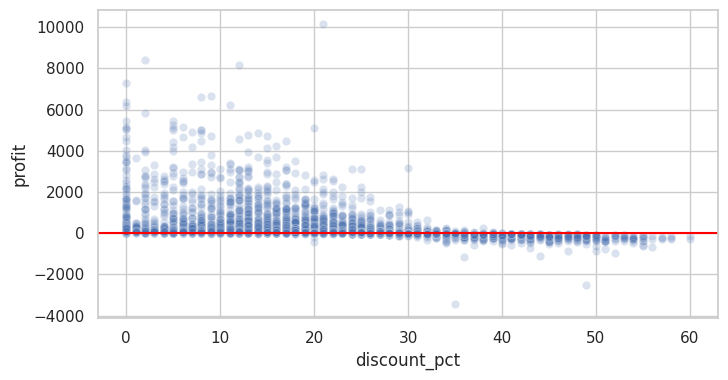

In [ ]:
sns.scatterplot(data=orders, x="discount_pct", y="profit", alpha=0.2)
plt.axhline(0, color="red")

In [ ]:
orders.head()

,order_date,month,category,region,prime_member,order_value,discount_pct,delivery_days,profit,date
0,2025-01-01,Jan,Fashion,West,Prime,1872.0,33.0,1.0,-112.0,2025-01-01
1,2025-01-01,Jan,Fashion,South,Non-Prime,908.0,54.0,1.7,-214.0,2025-01-01
2,2025-01-01,Jan,Beauty,East,Non-Prime,552.0,29.0,5.3,-4.0,2025-01-01
3,2025-01-01,Jan,Home & Kitchen,East,Prime,1674.0,30.0,2.0,37.0,2025-01-01
4,2025-01-01,Jan,Home & Kitchen,South,Non-Prime,820.0,39.0,2.1,-59.0,2025-01-01


<Axes: xlabel='prime_member', ylabel='delivery_days'>

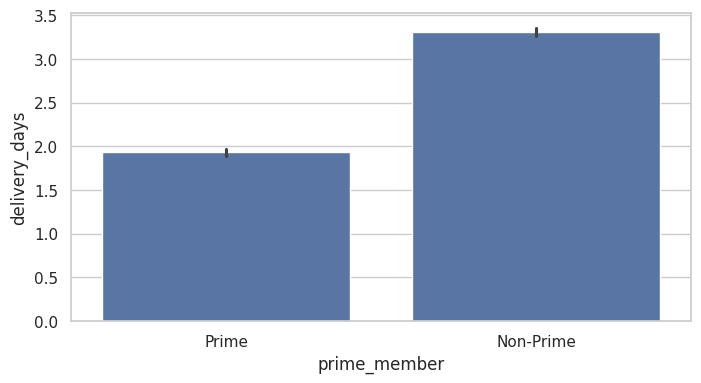

In [ ]:
# "Do prime delivers actually arrives faster?"
sns.barplot(data = orders, x='prime_member', y='delivery_days')

--
###  Ops has a complaint backlog about delivery speed.
###Question: is it a region problem or a Prime problem?


<Axes: xlabel='region', ylabel='delivery_days'>

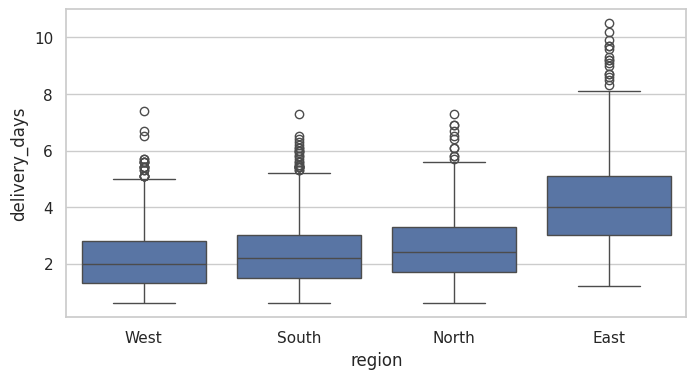

In [ ]:
speed_order = ["West", "South", "North", "East"]

sns.boxplot(data=orders, x="region", y="delivery_days", order=speed_order)

<Axes: xlabel='region', ylabel='delivery_days'>

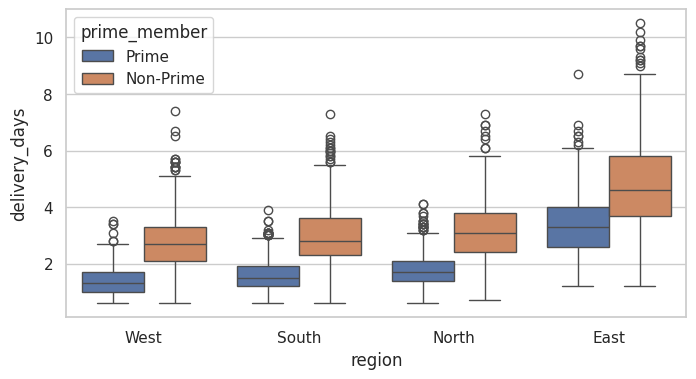

In [ ]:
sns.boxplot(data=orders, x="region", y="delivery_days", order=speed_order,
            hue="prime_member")

This is the chart ops needed, and it says something neither single chart could:

| Region | Non-Prime | Prime |
|---|---|---|
| West | 2.7 days | **1.3** |
| South | 2.8 | 1.5 |
| North | 3.1 | 1.7 |
| **East** | **4.6** | **3.3** |


### When two categories meet a number: `heatmap`

In [ ]:
# grid

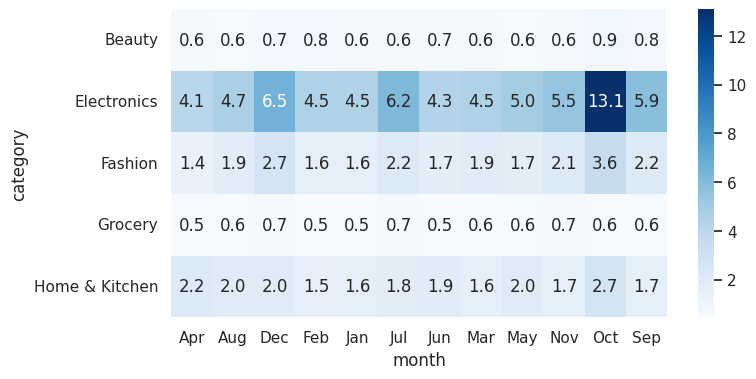

In [ ]:
grid = orders.pivot_table(index="category", columns="month",
                          values="order_value", aggfunc="sum") / 100000

sns.heatmap(grid, cmap="Blues", annot=True, fmt=".1f");

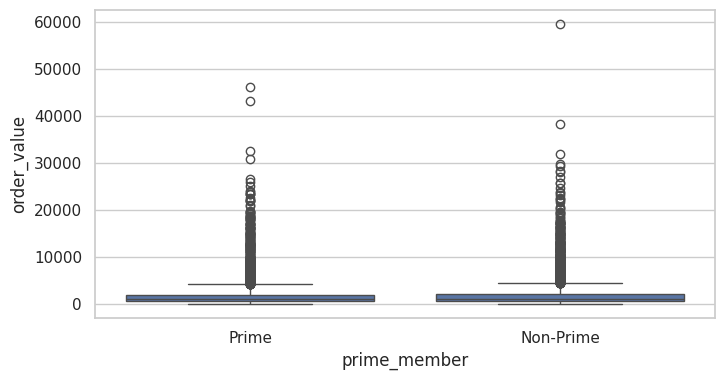

In [ ]:
# prime vs non-prime who spends more ?
sns.boxplot(data = orders, x = 'prime_member',  y = 'order_value');

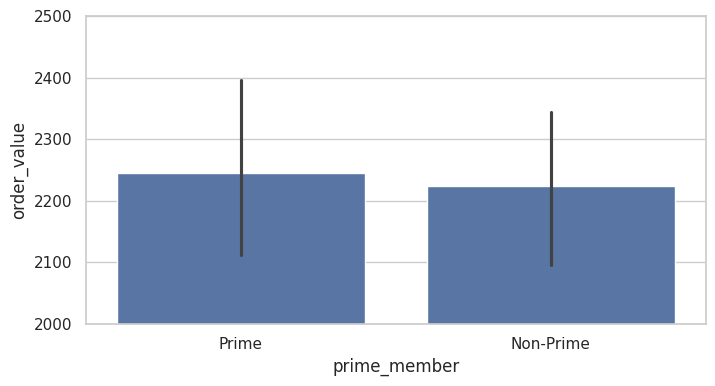

In [ ]:
sns.barplot(data = orders, x = 'prime_member',  y = 'order_value')
plt.ylim(2000, 2500);

In [ ]:
orders.groupby('prime_member')['order_value'].mean()

,order_value
prime_member,
Non-Prime,2223.303708
Prime,2245.334736


### Coloring

<Axes: xlabel='category', ylabel='order_value'>

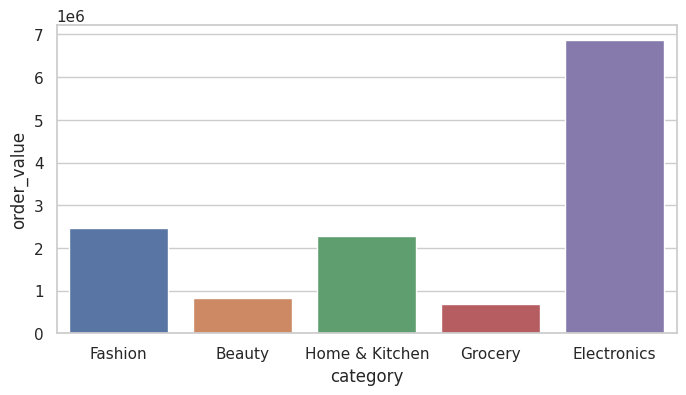

In [ ]:
sns.barplot(data=orders, x="category", y="order_value",
            estimator="sum", errorbar=None, hue="category")

<Axes: xlabel='category', ylabel='revenue'>

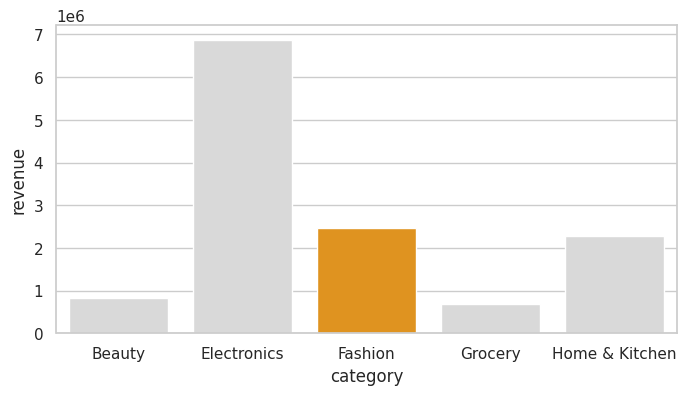

In [ ]:
by_cat = orders.groupby("category", as_index=False).agg(
    revenue=("order_value", "sum"), profit=("profit", "sum"))
by_cat["losing_money"] = by_cat["profit"] < 0

sns.barplot(data=by_cat, x="category", y="revenue", hue="losing_money",
            palette={True: "#ff9900", False: "#d9d9d9"}, legend=False)

<Axes: xlabel='category', ylabel='margin_pct'>

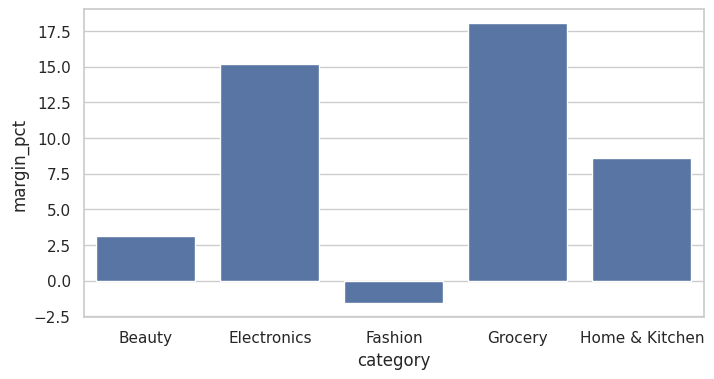

In [ ]:
# is discounting buying growth or buying losses? Revenue says Fashion is healthy. Margin says otherwise.

by_cat["margin_pct"] = 100 * by_cat["profit"] / by_cat["revenue"]

sns.barplot(data=by_cat, x="category", y="margin_pct")

<Axes: xlabel='margin_pct', ylabel='category'>

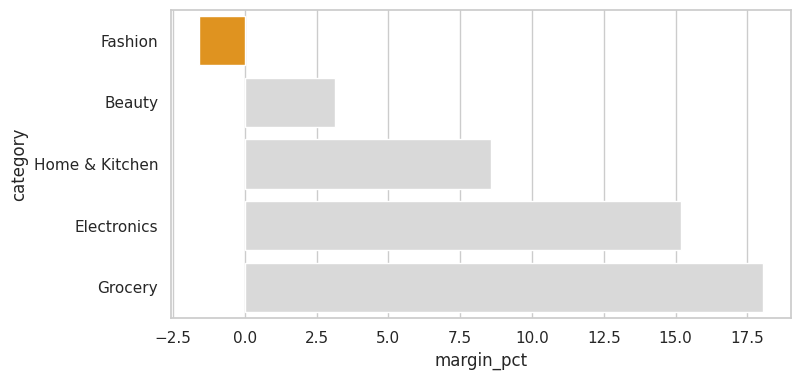

In [ ]:
by_cat = by_cat.sort_values("margin_pct")

sns.barplot(data=by_cat, y="category", x="margin_pct", hue="losing_money",
            palette={True: "#ff9900", False: "#d9d9d9"}, legend=False)

Text(0.5, 0, '-1.6% margin')

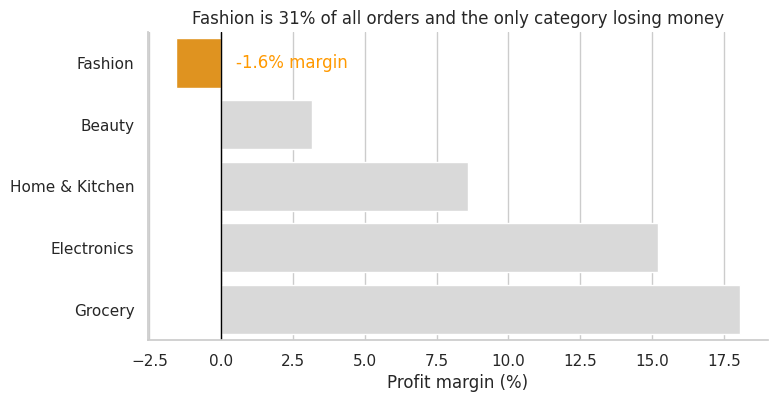

In [ ]:
worst = by_cat.iloc[0]
share = 100 * (orders["category"] == worst["category"]).mean()

sns.barplot(data=by_cat, y="category", x="margin_pct", hue="losing_money",
            palette={True: "#ff9900", False: "#d9d9d9"}, legend=False)
sns.despine()
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Profit margin (%)")
plt.ylabel("")
plt.title(f"{worst['category']} is {share:.0f}% of all orders "
          f"and the only category losing money")
plt.text(0.5, 0, f"{worst['margin_pct']:.1f}% margin", va="center", color="#ff9900")

---
## Section 4 — Declutter

Text(0.5, 1.0, 'Monthly Revenue')

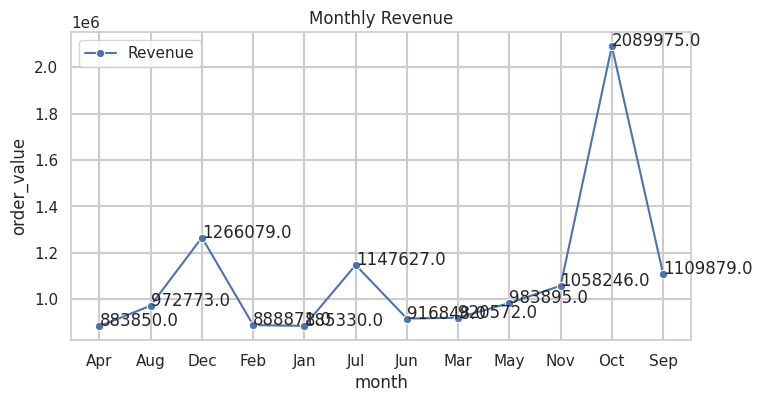

In [ ]:
monthly = orders.groupby("month", as_index=False)["order_value"].sum()

sns.lineplot(data=monthly, x="month", y="order_value", marker="o", label="Revenue")
plt.grid(True, linewidth=1.5)
for i, v in enumerate(monthly["order_value"]):
    plt.text(i, v, v)
plt.title("Monthly Revenue")

In [ ]:
# monthly

Text(0.5, 1.0, 'October carried the year: Rs 20.9 lakh')

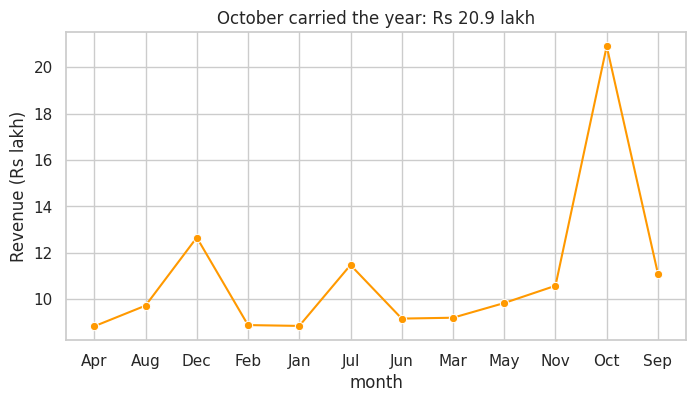

In [ ]:
sns.set_theme(style="whitegrid")          # set once, applies to every chart after this

monthly["revenue_lakh"] = monthly["order_value"] / 100000

sns.lineplot(data=monthly, x="month", y="revenue_lakh", marker="o", color="#ff9900")
plt.ylabel("Revenue (Rs lakh)")
plt.title(f"October carried the year: Rs {monthly['revenue_lakh'].max():.1f} lakh")

---
### Is discounting buying growth or buying losses?* Revenue says Fashion is healthy. Margin says otherwise.

Your rules:
1. **Sort** by value — not alphabetically
2. **Highlight one thing**, grey the rest
3. **Compute the title from the data**, never type the number
4. **Annotate** the one point that carries the argument



In [ ]:
# is discounting buying growth or buying losses? Revenue says Fashion is healthy. Margin says otherwise.

by_cat["margin_pct"] = 100 * by_cat["profit"] / by_cat["revenue"]

sns.barplot(data=by_cat, x="category", y="margin_pct")

In [ ]:
by_cat = by_cat.sort_values("margin_pct")

sns.barplot(data=by_cat, y="category", x="margin_pct", hue="losing_money",
            palette={True: "#ff9900", False: "#d9d9d9"}, legend=False)
sns.despine()

In [ ]:
worst = by_cat.iloc[0]
share = 100 * (orders["category"] == worst["category"]).mean()

sns.barplot(data=by_cat, y="category", x="margin_pct", hue="losing_money",
            palette={True: "#ff9900", False: "#d9d9d9"}, legend=False)
sns.despine()
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Profit margin (%)")
plt.ylabel("")
plt.title(f"{worst['category']} is {share:.0f}% of all orders "
          f"and the only category losing money")
plt.text(0.5, 0, f"{worst['margin_pct']:.1f}% margin", va="center", color="#ff9900")

In [ ]:
avg_disc = orders.loc[orders["category"] == "Fashion", "discount_pct"].mean()

sns.regplot(data=orders, x="discount_pct", y="profit",
            scatter_kws={"alpha": 0.15, "color": "#d9d9d9"}, line_kws={"color": "#ff9900"})
sns.despine()
plt.axhline(0, color="black", linewidth=1)
plt.axvline(avg_disc, color="#ff9900", linestyle="--")
plt.ylim(-2000, 4000)
plt.title(f"Profit crosses zero at ~30% discount. Fashion averages {avg_disc:.0f}%.")

---
## Summary Charts

In [ ]:
by_region = orders.groupby("region", as_index=False)["order_value"].sum()
by_region["revenue_lakh"] = by_region["order_value"] / 100000

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=by_region, x="region", y="revenue_lakh", color="#ff9900", ax=ax[0])
sns.barplot(data=by_region, x="region", y="revenue_lakh", color="#ff9900", ax=ax[1])
ax[1].set_ylim(20, 37)
ax[0].set_title("Honest — axis starts at 0")
ax[1].set_title("Same data, axis starts at 20")

In [ ]:
sns.lineplot(data=by_cat, x="category", y="margin_pct", marker="o")